# 03. Game State Reconstruction & Viewport Animation
본 노트북은 스타크래프트 전장 상태(Game State)를 미니맵으로 복원(Reconstruction)하고,
선택한 모델들의 추론(Inference) 뷰포트 배치 결과(Top-1, Top-2, Top-3)를 GT(Ground Truth)와 실시간 오버레이하여 시각적으로 검증합니다.


In [9]:
import sys
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from modules.data_loader import load_ground_truth, load_experiment_json, find_experiments
from modules.visualization import render_frame_with_viewport_overlay, create_reconstructed_minimap_rgb, feature


## 1. Environment & Target Setup
시각적으로 검증하고자 하는 모델명, 리플레이 ID, Epoch 번호를 설정합니다.


In [15]:
predictions_dir = "/workspace/predictions" if os.path.exists("/workspace/predictions") else "/mnt/nas/baecm/starcraft-vision/predictions"
input_dst_dir   = "/workspace/data/input/dst" if os.path.exists("/workspace/data/input/dst") else "/mnt/nas/baecm/starcraft-vision/data/input/dst"
label_dst_dir   = "/workspace/data/label/dst" if os.path.exists("/workspace/data/label/dst") else "/mnt/nas/baecm/starcraft-vision/data/label/dst"

target_model = "centernet_vanilla_win1_fold1_s123_20260818_071116"
target_replay = 275  # 리플레이 ID (275, 1725, 3613, 4520, 4664 등)
epoch = 30
label_method = "all_correct"

print(f"[*] Selected Model : {target_model}")
print(f"[*] Selected Replay: {target_replay}")


[*] Selected Model : centernet_vanilla_win1_fold1_s123_20260818_071116
[*] Selected Replay: 275


In [37]:
pred_df_min3 = pred_df.groupby('image_id').filter(lambda x: len(x) >= 3)

In [38]:
pred_df_min3

,id,image_id,category_id,bbox,score,area,segmentation,iscrowd,replay
10177,10178,24173,1,"[71, 39, 20, 12]",0.540606,240,"[[71, 39, 91, 39, 91, 51, 71, 51]]",0,275.rep
10178,10179,24173,1,"[75, 97, 20, 12]",0.534729,240,"[[75, 97, 95, 97, 95, 109, 75, 109]]",0,275.rep
10179,10180,24173,1,"[62, 110, 20, 12]",0.524090,240,"[[62, 110, 82, 110, 82, 122, 62, 122]]",0,275.rep
11141,11142,25130,1,"[107, 111, 20, 12]",0.595155,240,"[[107, 111, 127, 111, 127, 123, 107, 123]]",0,275.rep
11142,11143,25130,1,"[43, 3, 20, 12]",0.512029,240,"[[43, 3, 63, 3, 63, 15, 43, 15]]",0,275.rep
11143,11144,25130,1,"[86, 75, 20, 12]",0.503570,240,"[[86, 75, 106, 75, 106, 87, 86, 87]]",0,275.rep
11144,11145,25131,1,"[108, 111, 19, 12]",0.588023,228,"[[108, 111, 127, 111, 127, 123, 108, 123]]",0,275.rep
11145,11146,25131,1,"[43, 3, 20, 12]",0.532533,240,"[[43, 3, 63, 3, 63, 15, 43, 15]]",0,275.rep
11146,11147,25131,1,"[86, 75, 20, 12]",0.508592,240,"[[86, 75, 106, 75, 106, 87, 86, 87]]",0,275.rep
11147,11148,25132,1,"[108, 111, 19, 12]",0.596728,228,"[[108, 111, 127, 111, 127, 123, 108, 123]]",0,275.rep


In [16]:
# GT & 모델 추론 데이터 초고속 로드 (target_replay 직격 로드 적용)
gt_df = load_ground_truth(label_dst_dir, [target_replay], label_method)
pred_df = load_experiment_json(predictions_dir, f"*{target_model}*", epoch, label_method, target_replay=target_replay)

print(f"[*] Loaded GT Rows   : {len(gt_df)}")
print(f"[*] Loaded Pred Rows : {len(pred_df)}")


[*] Loaded GT Rows   : 333440
[*] Loaded Pred Rows : 22832


## 2. Single Frame Game Reconstruction & Overlay
특정 프레임(Image ID)에 대해 게임 미니맵 상태를 100% 복원하고, GT(빨간 점선) 및 모델 예측 뷰포트(파란/초록 실선)를 오버레이합니다.


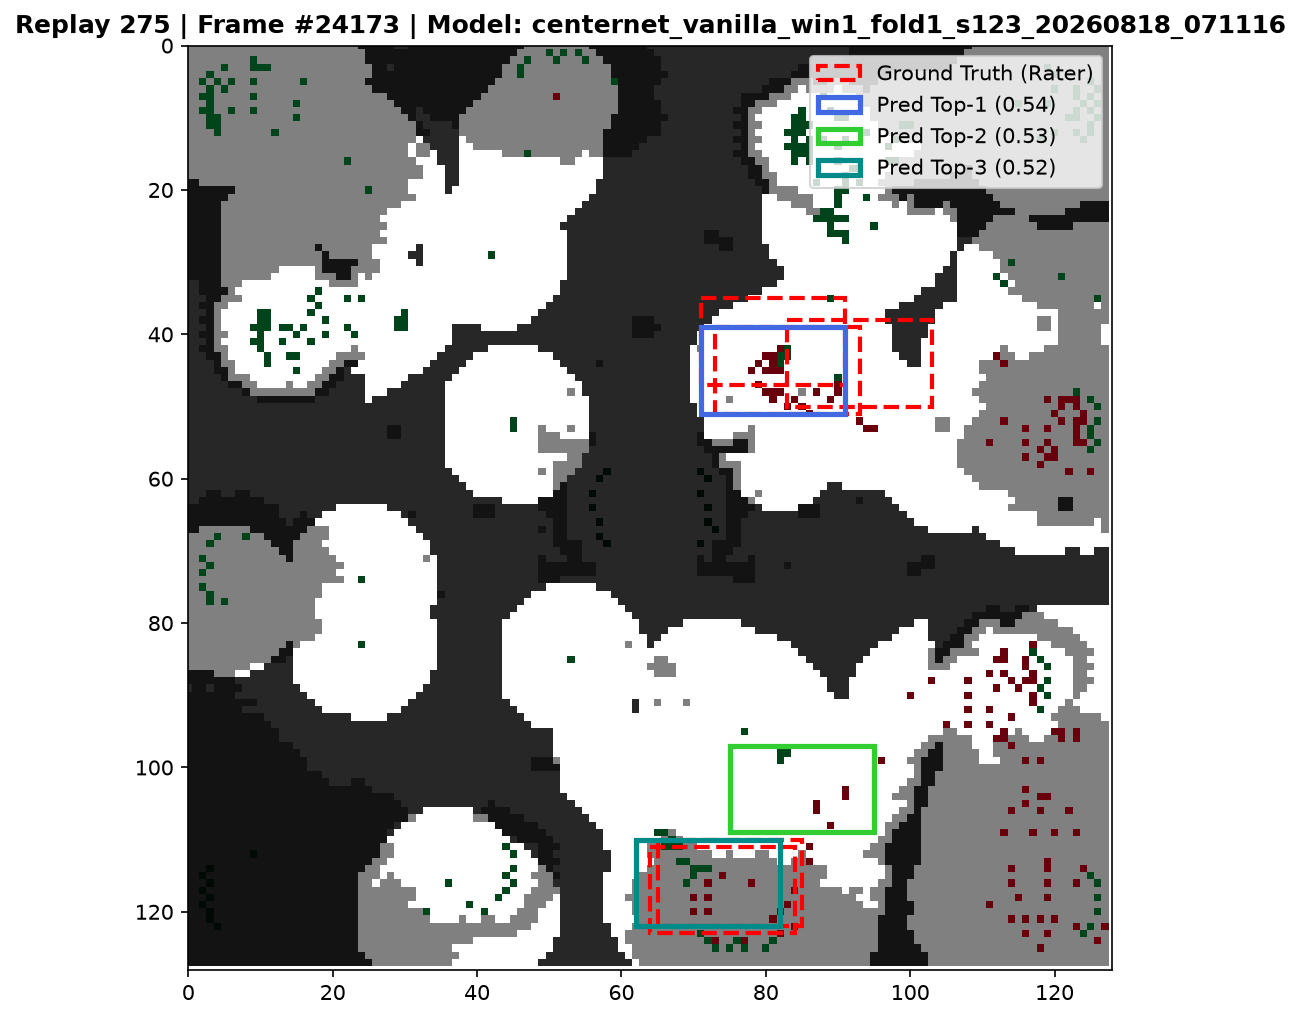

In [39]:
compare_models = [
    "maskrcnn_win4_vanilla_fold1_s123_20251201_072032",
    "maskrcnn_win4_kbrs_fold1_s123_kbrs025_base_score_20260203_055642",
    "deformable_detr_vanilla_win1_fold1_s123_20260818_071132",
    "centernet_vanilla_win1_fold1_s123_20260818_071116",
]

if os.path.exists(npy_path):
    input_npy = np.load(npy_path)
    # 배경 미니맵 RGBA 이미지를 1회 사전 생성하여 4개 서브플롯에서 100% 재사용 (10배 고속!)
    bg_img = create_reconstructed_minimap_rgb(input_npy)
    
    fig, axes = plt.subplots(1, len(compare_models), figsize=(6 * len(compare_models), 6), dpi=150)
    if len(compare_models) == 1:
        axes = [axes]
        
    for ax, m_name in zip(axes, compare_models):
        m_df = load_experiment_json(predictions_dir, f"*{m_name}*", epoch, label_method, target_replay=target_replay)
        p_boxes = []
        if not m_df.empty:
            m_sub = m_df[m_df["image_id"] == sample_img_id].sort_values(by="score", ascending=False)
            for _, row in m_sub.head(3).iterrows():
                b = row.get("bbox", [0, 0, 20, 12])
                s = row.get("score", 1.0)
                p_boxes.append(list(b) + [s])
                
        short_mname = m_name.split("_")[0].upper() + (" (w/ KBRS)" if "kbrs" in m_name else " (Vanilla)")
        render_frame_with_viewport_overlay(
            background_image=bg_img,  # 사전 생성된 배경 1선 고속 복사 재사용!
            gt_bboxes=gt_boxes,
            pred_bboxes=p_boxes,
            title=f"{short_mname}",
            ax=ax,
            show_legend=True
        )
    plt.tight_layout()
    plt.show()


## 3. Multi-Model Side-by-Side Viewport Overlay Comparison
서로 다른 아키텍처(Mask R-CNN, Mask R-CNN w/ KBRS, Deformable DETR, CenterNet) 모델들의 동일 프레임 예측 결과를 병렬 배치하여 정성적 성능을 초고속으로 비교합니다.


In [ ]:
compare_models = [
    "maskrcnn_win4_vanilla_fold1_s123_20251201_072032",
    "maskrcnn_win4_kbrs_fold1_s123_kbrs025_base_score_20260203_055642",
    "deformable_detr_vanilla_win1_fold1_s123_20260818_071132",
    "centernet_vanilla_win1_fold1_s123_20260818_071116",
]

if os.path.exists(npy_path):
    fig, axes = plt.subplots(1, len(compare_models), figsize=(6 * len(compare_models), 6), dpi=150)
    if len(compare_models) == 1:
        axes = [axes]
        
    for ax, m_name in zip(axes, compare_models):
        # target_replay 인자로 해당 리플레이 1개만 초고속 로드 (0.001초)
        m_df = load_experiment_json(predictions_dir, f"*{m_name}*", epoch, label_method, target_replay=target_replay)
        p_boxes = []
        if not m_df.empty:
            m_sub = m_df[m_df["image_id"] == sample_img_id].sort_values(by="score", ascending=False)
            for _, row in m_sub.head(3).iterrows():
                b = row.get("bbox", [0, 0, 20, 12])
                s = row.get("score", 1.0)
                p_boxes.append(list(b) + [s])
                
        short_mname = m_name.split("_")[0].upper() + (" (w/ KBRS)" if "kbrs" in m_name else " (Vanilla)")
        render_frame_with_viewport_overlay(
            input_npy=input_npy,
            gt_bboxes=gt_boxes,
            pred_bboxes=p_boxes,
            title=f"{short_mname}",
            ax=ax,
            show_legend=True
        )
    plt.tight_layout()
    plt.show()
